In [1]:
# Import Libraries
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the train and test datasets
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

In [3]:
# What are the columns in the dataset?
print("Columns in the training dataset:")
df_train.columns

Columns in the training dataset:


Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [4]:
# View the first few rows of the DataFrame
#df_train.head()
df_test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [5]:
# Data Shape
df_train.shape, df_test.shape   

((891, 12), (418, 11))

In [6]:
# We want to merge test and train datasets to do some EDA and feature engineering. We will separate them later on.
# But before that we will add a Survived column to the test dataset and fill it with NaN values. 
# This will help us to identify the test dataset after merging.

df_test['Survived'] = np.nan

df_test.shape
df_test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,NaN
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,NaN
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,NaN
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,NaN
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,NaN


In [7]:
# Now we can merge the datasets
df = pd.concat([df_train, df_test], ignore_index=True)
# Now we can check the shape of the merged dataset
df.shape

(1309, 12)

In [8]:
df.head()
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,1309.000000,891.000000,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000
mean,655.000000,0.383838,2.294882,29.881138,0.498854,0.385027,33.295479
std,378.020061,0.486592,0.837836,14.413493,1.041658,0.865560,51.758668
min,1.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,328.000000,0.000000,2.000000,21.000000,0.000000,0.000000,7.895800
50%,655.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,982.000000,1.000000,3.000000,39.000000,1.000000,0.000000,31.275000
max,1309.000000,1.000000,3.000000,80.000000,8.000000,9.000000,512.329200


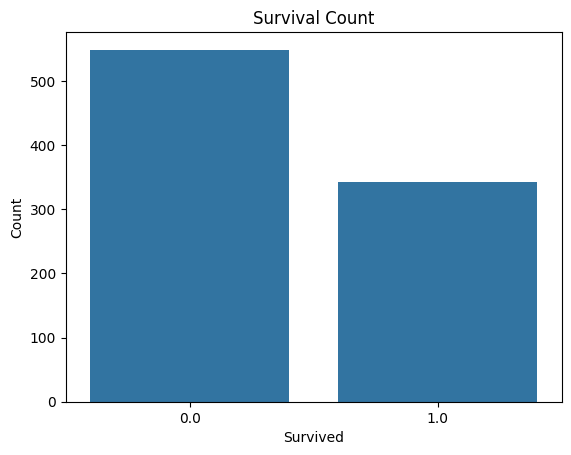

In [9]:
# Visualize the Survival Trends

# Let's visualize the count of survivors and non-survivors in the dataset.
import matplotlib.pyplot as plt

sns.countplot(data=df, x='Survived')
plt.title('Survival Count')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.show()

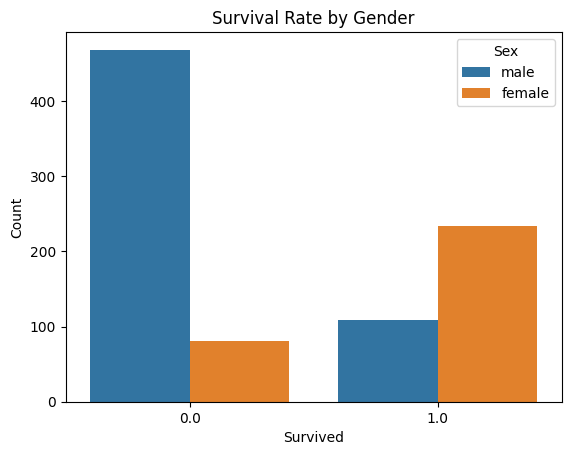

In [10]:
# Visualize Survival Rate by Gender
sns.countplot(data=df, x='Survived', hue='Sex')
plt.title('Survival Rate by Gender')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.show()

In [11]:
# Drop columns that are too sparse or irrelevant to the model.
#We are going to drop the following columns:
# - Cabin: This column has a lot of missing values and is not likely to be useful
# - Ticket: This column is not likely to be useful for predicting survival and has many unique values.
# - Name: This column is not likely to be useful for predicting survival and has many unique values.
df.drop(['Cabin', 'Ticket', 'Name'], axis=1, inplace=True)
df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0.0,3,male,22.0,1,0,7.2500,S
1,2,1.0,1,female,38.0,1,0,71.2833,C
2,3,1.0,3,female,26.0,0,0,7.9250,S
3,4,1.0,1,female,35.0,1,0,53.1000,S
4,5,0.0,3,male,35.0,0,0,8.0500,S


In [12]:
#Next we will check for missing values in the dataset and handle them accordingly. 
# We will use the following strategies to handle missing values:
# - For numerical columns, we will fill the missing values with the median of the column.
# - For categorical columns, we will fill the missing values with the mode of the column.
# Check for missing values
df.isnull().sum()

# Fill missing values for numerical columns with the median one by one
# In this case we have only one numerical column with missing values which is Age, so we will fill it with the median of the Age column.
df['Age'].fillna(df['Age'].median(), inplace=True)


# Fill missing values for categorical columns with the mode
# In this case we have only one categorical column with missing values which is Embarked, so we will fill it with the mode of the Embarked column.
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)


# Check for missing values again to confirm that they have been handled
df.isnull().sum()

df.head()


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_23212\2715578176.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_23212\2715578176.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0.0,3,male,22.0,1,0,7.2500,S
1,2,1.0,1,female,38.0,1,0,71.2833,C
2,3,1.0,3,female,26.0,0,0,7.9250,S
3,4,1.0,1,female,35.0,1,0,53.1000,S
4,5,0.0,3,male,35.0,0,0,8.0500,S


In [13]:
# Now we will check the data types of the columns and convert them to the appropriate data types if necessary.
df.dtypes
df.head()


,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0.0,3,male,22.0,1,0,7.2500,S
1,2,1.0,1,female,38.0,1,0,71.2833,C
2,3,1.0,3,female,26.0,0,0,7.9250,S
3,4,1.0,1,female,35.0,1,0,53.1000,S
4,5,0.0,3,male,35.0,0,0,8.0500,S


In [14]:
#We can work save the cleaned and preprocessed dataset to a new CSV file for future use.
df.to_csv('titanic_cleaned.csv', index=False)

In [15]:
# Select the features and target variable for the model
# We will select the following features for our model:  
# - Pclass: Passenger class (1st, 2nd, 3rd)
# - Sex: Gender
# - Age: Age of the passenger
# - SibSp: Number of siblings/spouses aboard the Titanic
# - Parch: Number of parents/children aboard the Titanic
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch']
#target = 'Survived'

#Assign the features and target variable to X and y respectively
X = df[features]    
y = df.Survived


In [16]:
# Split the data back into train and test datasets
X_train = X[:len(df_train)]
X_test = X[len(df_train):]
y_train = y[:len(df_train)]
y_test = y[len(df_train):]

In [17]:
y_test.head()
y_test.shape

(418,)

In [18]:
# Define and fit a machine learning model to the training data. 
# We will use a simple logistic regression model for this task.
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)



ValueError: could not convert string to float: 'male'